In [27]:
from pathlib import Path

import jax.numpy as jnp
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy import stats
from scipy.special import beta as beta_func
from scipy.special import binom as binom_func


In [28]:
sns.set_style("whitegrid")

ASSIGNMENT_DIR = Path().resolve().parent
REPORT_DIR = ASSIGNMENT_DIR / "report"
OUTPUT_DIR = REPORT_DIR / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

EXPORT_DPI = 600

MM_PER_INCH = 25.4
A4_WIDTH_MM = 210
PAGE_WIDTH_IN = (A4_WIDTH_MM - 2 * 15) / MM_PER_INCH

# Task 1

In [29]:
a_0 = 1
b_0 = 1
y = 4
N = 115
N_star = 20

# Posterior
a_post = a_0 + y
b_post = b_0 + N - y


## Task 1.1

In [30]:
from scipy import stats

p = 0.95
alpha = 1 - p

stats.beta.interval(1-alpha, a_0, b_0)

(np.float64(0.025000000000000022), np.float64(0.975))

## Task 1.2

In [31]:
mean_post = a_post / (a_post + b_post)
print(f"Posterior mean: {mean_post:.4f}")

l_post, u_post = stats.beta.interval(1-alpha, a_post, b_post)
print(f"Posterior 95% interval: [{l_post:.4f}, {u_post:.4f}]")

Posterior mean: 0.0427
Posterior 95% interval: [0.0141, 0.0859]


## Task 1.3

Mean of posterior predictive distribution: 0.8547
mean 0.8547008547008548


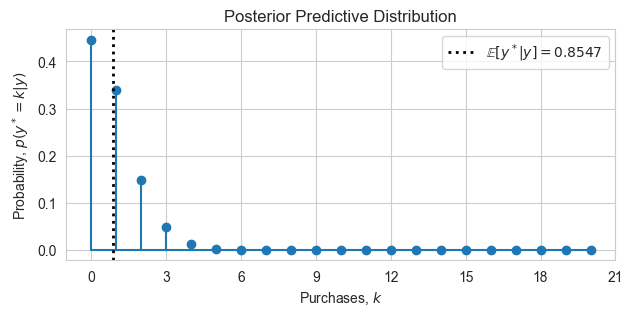

In [32]:
# Comparing expression from report with scipy documentation for betabinom:
from matplotlib.pylab import mean


a_betabinom = a_0 + y
b_betabinom = b_0 + N - y

y_star_dist_scipy = stats.betabinom(a=a_betabinom, b=b_betabinom, n=N_star)
# y_star_dist = stats.beta(a_post, b_post)
# y_star = y_star_dist_scipy.


ks = jnp.arange(0, N_star+1)
p_y_star_scipy = y_star_dist_scipy.pmf(ks)

def normalize(k):
    return beta_func(k+a_0+y, N_star-k+b_0+N-y) / beta_func(a_0+y, b_0+N-y)
p_y_star_manual = normalize(ks) * binom_func(N_star, ks)

mean_manual = jnp.sum(ks * p_y_star_scipy)
mean_scipy = y_star_dist_scipy.mean()
print(f"Mean of posterior predictive distribution: {mean_scipy:.4f}")

plt.figure(figsize=(PAGE_WIDTH_IN, 3))
plt.stem(ks, p_y_star_scipy, basefmt="")
plt.axvline(mean_scipy, color="k", lw=2, ls=":", label=f"$\\mathbb{{E}}[y^*|y] = {mean_scipy:.4f}$")
plt.title("Posterior Predictive Distribution")
plt.xlabel("Purchases, $k$")
plt.ylabel("Probability, $p(y^* = k | y)$")
plt.legend()
plt.gca().xaxis.set_major_locator(mpl.ticker.MaxNLocator(integer=True))
plt.savefig(OUTPUT_DIR / "1_3_ppd.png", dpi=EXPORT_DPI, bbox_inches="tight")
# sns.histplot(p_y_star, bins=10, kde=True)

print("mean", y_star_dist_scipy.mean())

## Task 1.4

In [33]:
p0 = y_star_dist_scipy.pmf(k=0)
print(f"Probability of no purchases in next 20 customers: {p0:.4f}")
1 - y_star_dist_scipy.pmf(k=0)
print(f"Probability of at least 1 purchase in next 20 customers: {1 - p0:.4f}")

Probability of no purchases in next 20 customers: 0.4456
Probability of at least 1 purchase in next 20 customers: 0.5544


In [34]:
print(y_star_dist_scipy.mean())
print(y_star_dist_scipy.var())

0.8547008547008548
0.9499152480464954
